In [ ]:
import pandas as pd
import numpy as np
import os
import zipfile
import re
import geopandas as gpd
import plotly.graph_objects as go
from shapely.wkt import loads
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib.colors import LogNorm

# Dados - IPTU

O objetivo do código é realizar o georreferenciamento da base de dados do IPTU a fim de conectar as informações do preço do metro quadrado do imóvel com o setor censitário ao qual ele pertence. Dessa maneria, é possível calcular o valor médio do metro quadrado do setor censitário para imóveis residênciais. Para isso foram utilizadas algumas bibliotecas, principalmente, sf para manipulação dos dados e dplyr para realizar a manipulação tabular.

## Obtenção dos dados

Dados do IPTU sofrem renovação constantemente. Por isso, é necessário realizar seu download sempre que necessário no página do GeoSampa em: <https://geosampa.prefeitura.sp.gov.br/>, na pasta 'Cadastro'. Para que o código funcione, armazene-o em uma pasta chamada 'IPTU_2024' no mesmo diretório que este código.

Os dados sobre os lotes no Estado de São Paulo encontram-se, também, na página do GeoSampa na pasta 'Cadastro'. Armazene todos os zips em uma pasta cujo caminho seja 'dados/lotes/zip'. O código a baixo é responsável por descompactar todos os arquivos e juntá-los em arquivos s 'combinado' e será criada a pasta para armazená-los.

Os dados do censo de 2022 são encontrados no site do IBGE no link abaixo. '<https://ftp.ibge.gov.br/Censos/Censo_Demografico_2022/Agregados_por_Setores_Censitarios_preliminares/agregados_por_setores_xlsx/UF/>' Armazeno-o em uma pasta nomeada 'SP_Malha_Preliminar_2022' no mesmo diretório deste código.

## Metodologia

Após baixar os dados brutos, é necessário realizar um tratamento. Para os dados do IPTU, apenas os imóveis 'Residenciais' foram selecionados e seu SQL (setor-quadra-lote) dos imóveis foram identificados. Com isso, foi possível juntar esta base os dados sobre os lotes fiscais georreferenciados através do código SQL. Este georreferenciamento é muito importante por ser o responsável por juntar esta base com a do Senso de 2022, que possui o código do setor censitário.

## Resultados

Foi possível adiquirir uma base de dados dois formatos: excel (xlsx) e shapefile (shp), Em ambos os casos, existe informações sobre o preço médio do valor do metro quadrado em cada setor censitário de São Paulo. O segundo, no entanto, é georreferenciado. Pode-se ressaltar que, devido às junções nas bases de dados, o método pussui um erro de aproximadamente 1,7%.

## Mapas e Imagens

Com a base de dados obtida, foi possível obter alguns mapas e imagens acerca dos dados fornecidos, que incluem a quantidade de condomínios na cidade em relação a lotes com uma única moradia, histograma que relaciona o preço do metro quadrado do imóvel com seu tamanho, o preço do metro quadrado em relação à região onde se encontra na cidade e os diferentes tipos de moradia presentes na base de dados.

## Bases de dados
IPTU

In [3]:
IPTU_original = pd.read_csv("../dados/IPTU_2024/IPTU_2024.csv", sep=";", encoding="latin1", dtype=str)

Lotes

In [ ]:
lotes_path = "../dados/lotes"
zip_path = os.path.join(lotes_path, "zip")
unzip_path = os.path.join(lotes_path, "unzip")


if "zip" not in os.listdir(lotes_path):
    arquivos_zip = [re.sub(r"\.zip$", "", f) for f in os.listdir(zip_path)]

    for file in arquivos_zip:
        file_zip_path = os.path.join(zip_path, f"{file}.zip")

        with zipfile.ZipFile(file_zip_path, 'r') as zip_ref:
            for ext in [".shp", ".dbf", ".shx"]:
                file_to_extract = f"{file}/{file}{ext}"

                if file_to_extract in zip_ref.namelist():
                    zip_ref.extract(file_to_extract, path=unzip_path)

In [ ]:
combinado_dir = "lotes/combinado"
if not os.path.exists(combinado_dir):
    os.makedirs(combinado_dir, exist_ok=True)

shapefiles = [os.path.join("lotes/unzip", f, f"{f}.shp") for f in os.listdir("lotes/unzip")]

lotes_combinados = gpd.GeoDataFrame(pd.concat([gpd.read_file(shp) for shp in shapefiles], ignore_index=True))
lotes_combinados.set_crs(epsg=31983, inplace=True)
lotes_combinados.to_file("lotes/combinado/lotes_combinados.shp", driver="ESRI Shapefile")

In [6]:
lotes_real = gpd.read_file("../dados/lotes/combinado/lotes_combinados.shp")
lotes_real.set_crs(epsg=31983,allow_override=True ,inplace=True)  

,lo_setor,lo_quadra,lo_lote,lo_condomi,lo_tp_quad,lo_tp_lote,geometry
0,052,053,0015,00,F,F,"POLYGON ((338796.776 7393110.684, 338802.606 7..."
1,052,078,0070,00,F,F,"POLYGON ((339772.27 7392871.973, 339772.204 73..."
2,053,045,0038,00,F,F,"POLYGON ((340427.172 7392801.404, 340429.553 7..."
3,052,024,0147,00,F,F,"POLYGON ((338698.996 7392112.563, 338691.275 7..."
4,052,024,0148,00,F,F,"POLYGON ((338698.996 7392112.563, 338695.432 7..."
...,...,...,...,...,...,...,...
1677975,115,037,0048,00,F,F,"POLYGON ((356461.627 7395469.613, 356456.724 7..."
1677976,193,046,0007,00,F,F,"POLYGON ((357832.528 7396011.824, 357838.681 7..."
1677977,193,046,0015,00,F,F,"POLYGON ((357852.413 7395995.586, 357856.661 7..."
1677978,193,014,0018,00,F,F,"POLYGON ((357723.091 7396368.457, 357722.316 7..."


In [7]:
lotes = lotes_real[lotes_real["lo_tp_lote"] == "F"].copy()
lotes["lo_lote"] = lotes.apply(lambda row: f"CD{row['lo_condomi']}" if row["lo_lote"] == "0000" else row["lo_lote"], axis=1)
lotes = lotes.rename(columns={"lo_setor": "setor", "lo_quadra": "quadra", "lo_lote": "lote"})[["setor", "quadra", "lote","geometry"]]

Censo

In [8]:
censo = gpd.read_file("../dados/SP_Malha_Preliminar_2022/SP_Malha_Preliminar_2022.shp")

In [9]:
censo = censo[censo["CD_MUN"] == "3550308"].copy()
censo = censo.to_crs(epsg=31983)

censo = censo.rename(columns={"CD_SETOR": "id_setor_censitario"})[["id_setor_censitario", "geometry"]]
censo["area_setor"] = censo["geometry"].area.astype(float)

censo = censo.explode(index_parts=False).reset_index(drop=True)

Distrito de São Paulo

In [29]:
distrito = gpd.read_file("../dados/SIRGAS_SHP_distrito/SIRGAS_SHP_distrito/SIRGAS_SHP_distrito.shp")
distrito = distrito.set_crs(epsg=31983)  
distrito = distrito.to_crs(epsg=31983)

## Dados do IPTU

In [10]:
IPTU_util = IPTU_original.rename(columns={
    "NUMERO DO CONTRIBUINTE": "sql",
    "NUMERO DO CONDOMINIO": "condominio",
    "AREA DO TERRENO": "area_terreno",
    "BAIRRO DO IMOVEL": "bairro",
    "VALOR DO M2 DO TERRENO": "valor_m2_terreno",
    "TIPO DE PADRAO DA CONSTRUCAO": "tipo"
})

IPTU_util["setor"] = IPTU_util["sql"].str[:3]
IPTU_util["quadra"] = IPTU_util["sql"].str[3:6]

IPTU_util["lote"] = np.where(
    IPTU_util["condominio"] == "00-0",
    IPTU_util["sql"].str[6:10],
    "CD" + IPTU_util["condominio"].str[:2]
)

IPTU_util["residencial"] = IPTU_util["tipo"].str.contains("Residencial", na=False)

In [11]:
IPTU = IPTU_util[IPTU_util["residencial"] == 1].copy()

IPTU["area_terreno"] = pd.to_numeric(IPTU["area_terreno"], errors="coerce")
IPTU["valor_m2_terreno"] = pd.to_numeric(IPTU["valor_m2_terreno"], errors="coerce")
IPTU["residencial"] = pd.to_numeric(IPTU["residencial"], errors="coerce")

IPTU = IPTU.groupby(["setor", "quadra", "lote"]).agg(
    unidades=("residencial", "count"),
    area_terreno=("area_terreno", "median"),
    valor_m2_terreno=("valor_m2_terreno", "median"),
    residencial=("residencial", "median")
).reset_index()

## Georreferenciamento do IPTU

In [12]:
IPTU_lote = IPTU.merge(lotes[["setor", "quadra", "lote", "geometry"]], on=["setor", "quadra", "lote"], how="left")
IPTU_lote = gpd.GeoDataFrame(IPTU_lote, geometry="geometry", crs=lotes.crs)

## IPTU com informações do setor censitário

In [13]:
IPTU_censo = gpd.overlay(censo, IPTU_lote, how="intersection")
IPTU_censo = IPTU_censo.rename(columns={"geometry": "geometria_intersec"})
IPTU_censo = pd.DataFrame(IPTU_censo)

IPTU_censo = IPTU_censo.merge(
    censo[["id_setor_censitario", "geometry"]].rename(columns={"geometry": "geometria_setor_censitario"}),
    on="id_setor_censitario",
    how="left"
)
IPTU_censo = IPTU_censo.merge(
    IPTU_lote[["setor", "quadra", "lote", "geometry"]].rename(columns={"geometry": "geometria_lote"}),
    on=["setor", "quadra", "lote"],
    how="left"
)

IPTU_censo = gpd.GeoDataFrame(IPTU_censo, geometry="geometria_intersec", crs=IPTU_lote.crs)
IPTU_censo["percent_intersec"] = IPTU_censo["geometria_intersec"].area / IPTU_censo["geometria_lote"].area

In [14]:
IPTU_censo_modificado = IPTU_censo.drop(columns=["geometria_lote", "geometria_intersec"])

In [15]:
IPTU_censo_modificado = IPTU_censo_modificado.set_geometry("geometria_setor_censitario")

valores_sc = IPTU_censo_modificado.dissolve(
    by="id_setor_censitario",
    aggfunc={
        "unidades": "sum",
        "valor_m2_terreno": "mean",
        "area_terreno": "mean",
    }
).reset_index()

KeyboardInterrupt: 

## Salvamento das bases de dados

In [ ]:
output_dir = "../dados/IPTU_censo"
os.makedirs(output_dir, exist_ok=True)  

In [ ]:
output_path = os.path.join(output_dir, "IPTU_censo.shp")
IPTU_censo_modificado.to_file(output_path)

In [ ]:
IPTU_censo_modificado = IPTU_censo_modificado.set_geometry("geometria_setor_censitario")

valores_sc = IPTU_censo_modificado.dissolve(
    by="id_setor_censitario",
    aggfunc={
        "unidades": "sum",
        "valor_m2_terreno": "mean",
        "area_terreno": "mean",
    }
).reset_index()


In [ ]:
output_path_valores_sc = os.path.join(output_dir, "valores_sc.shp")
IPTU_censo_modificado.to_file(output_path_valores_sc)

C:\Users\sergi\AppData\Local\Temp\ipykernel_39192\3352463250.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  IPTU_censo_modificado.to_file(output_path_valores_sc)
c:\Users\sergi\anaconda3\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'id_setor_censitario' to 'id_setor_c'
  ogr_write(
c:\Users\sergi\anaconda3\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'area_terreno' to 'area_terre'
  ogr_write(
c:\Users\sergi\anaconda3\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'valor_m2_terreno' to 'valor_m2_t'
  ogr_write(
c:\Users\sergi\anaconda3\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'residencial' to 'residencia'
  ogr_write(
c:\Users\sergi\anaconda3\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'percent_intersec' to 'percent_

## Erro
Durante a junção das bases de dados, pode existir um erro, que está relacionado com a junção entre as geometrias. Quando ocorre a junção das bases IPTU-georreferenciado com o censo, algumas geometrias não se equivalem totalmente, o que gera uma perda. 

In [16]:
df_bruta = IPTU[IPTU["residencial"] == 1].copy()
df_bruta["base"] = "bruta"

df_lote = IPTU_lote[~IPTU_lote.geometry.is_empty].copy()
df_lote["base"] = "Lote"

df_list = []
for df in [df_bruta, df_lote]:
    if "geometry" in df.columns:
        df = df.drop(columns=["geometry"])  
    if not df.empty:
        df_grouped = df.groupby("base", as_index=False).agg(unidades=("unidades", "sum"))
        df_list.append(df_grouped)

if df_list:
    result = pd.concat(df_list, ignore_index=True)
    if "base" in result.columns and "unidades" in result.columns:
        result = result.pivot_table(index=None, columns="base", values="unidades", aggfunc="sum")
        result["missing"] = result.get("bruta", 0) - result.get("Lote", 0)
        result["missing_percent"] = (100 * result["missing"] / result.get("bruta", 1)).round(2).astype(str) + "%"

        result = result.rename(columns={"Lote": "Critério de join", "missing": "Erros (unidades)", "missing_percent": "Percentual de erro"})


In [17]:
fig = go.Figure(data=[go.Table(
    header=dict(values=["<b>" + col + "</b>" for col in result.columns],
                fill_color="darkblue",
                font=dict(color="white", size=14),
                align="center"),
    cells=dict(values=[result[col] for col in result.columns],
               fill_color="lightgray",
               font=dict(size=12),
               align="center"))
])

fig.update_layout(
    title="Valores Totais de Unidades<br><sup>Comparação entre Lotes e Censo de Join</sup>",
    title_font=dict(size=18, family="Arial", color="black"),
    width=600, height=300
)

fig.show()

## MAPA: preço vs setor censitario

In [18]:
IPTU_censo_valores = IPTU_censo[["valor_m2_terreno", "geometria_setor_censitario"]].copy()

if isinstance(IPTU_censo_valores["geometria_setor_censitario"].iloc[0], str):
    IPTU_censo_valores["geometria_setor_censitario"] = IPTU_censo_valores["geometria_setor_censitario"].apply(loads)

IPTU_censo_valores = gpd.GeoDataFrame(IPTU_censo_valores, geometry="geometria_setor_censitario")

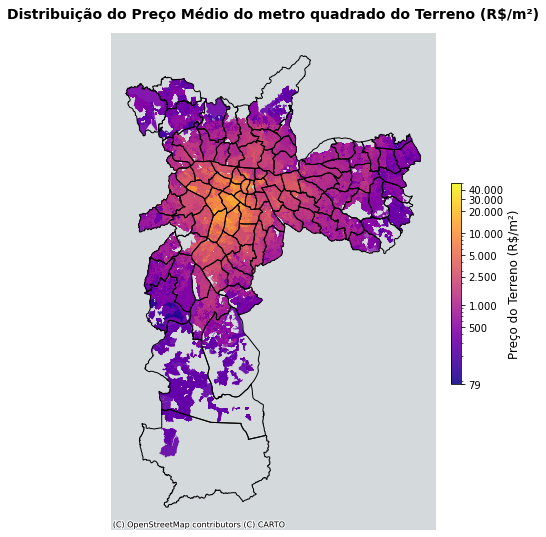

In [ ]:
intervalos = [79.9, 500, 1000, 2500, 5000, 10000, 20000, 30000, 40000]

fig, ax = plt.subplots(figsize=(7, 12))

IPTU_censo_valores.plot(column="valor_m2_terreno",
                        cmap="plasma",  
                        legend=False, 
                        alpha=0.9,
                        edgecolor=None,  
                        linewidth=0,
                        norm=LogNorm(vmin=79.9, vmax=50000), 
                        ax=ax)

distrito.boundary.plot(ax=ax, color="black", linewidth=1)  # Adiciona bordas dos distritos em preto

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

cbar = plt.colorbar(ax.collections[0], ax=ax, shrink=0.5, aspect=20, pad=0.02)
cbar.set_ticks(intervalos)
cbar.set_ticklabels([f"{int(tick):,}".replace(",", ".") for tick in intervalos])
cbar.set_label("Preço do Terreno (R$/m²)", fontsize=12)

ax.set_title("Distribuição do Preço Médio do metro quadrado do Terreno (R$/m²)", 
             fontsize=14, fontweight="bold", pad=15)
ax.axis("off")  

cbar.ax.set_position([0.8, 0.3, 0.02, 0.4])  
plt.show()

In [25]:
output_dir_SP = "../imagens"
os.makedirs(output_dir_SP, exist_ok=True)

output_path_SP = os.path.join(output_dir_SP, "mapa_precoxsetor_censitario_granulado.pdf")
plt.savefig(output_path_SP, bbox_inches="tight", dpi=300)

<Figure size 432x288 with 0 Axes>

## Quantidade de valores de metro quadrado

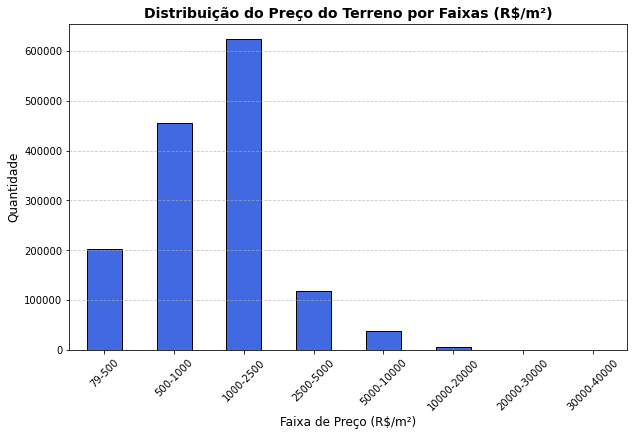

In [ ]:
intervalos = [79.9, 500, 1000, 2500, 5000, 10000, 20000, 30000, 40000]
legenda = ["79-500", "500-1000", "1000-2500", "2500-5000", 
           "5000-10000", "10000-20000", "20000-30000", "30000-40000"]

IPTU_censo["faixa_preco"] = pd.cut(IPTU_censo["valor_m2_terreno"], bins=intervalos, labels=legenda, right=True)

contagem = IPTU_censo["faixa_preco"].value_counts().reindex(legenda)

plt.figure(figsize=(10, 6))
contagem.plot(kind="bar", color="royalblue", edgecolor="black")

plt.xlabel("Faixa de Preço (R$/m²)", fontsize=12)
plt.ylabel("Quantidade", fontsize=12)
plt.title("Distribuição do Preço do Terreno por Faixas (R$/m²)", fontsize=14, fontweight="bold")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

In [ ]:
IPTU_censo["faixa_preco"] = pd.cut(
    IPTU_censo["valor_m2_terreno"], bins=intervalos, labels=legenda, right=False
)

contagem = IPTU_censo["faixa_preco"].value_counts().reindex(legenda).reset_index()
contagem.columns = ["Faixa de Preço (R$/m²)", "Quantidade"]

contagem["Porcentagem (%)"] = (contagem["Quantidade"] / contagem["Quantidade"].sum()) * 100

contagem

  Faixa de Preço (R$/m²)  Quantidade  Porcentagem (%)
0                 79-500      201717        13.985903
1               500-1000      455509        31.582389
2              1000-2500      622962        43.192622
3              2500-5000      117633         8.155999
4             5000-10000       37699         2.613833
5            10000-20000        6761         0.468769
6            20000-30000           6         0.000416
7            30000-40000           1         0.000069


## Altos preços de valor venal

In [38]:
setores_altos = IPTU_censo[IPTU_censo["faixa_preco"].isin(["20000-30000", "30000-40000"])]
setores_altos = setores_altos.to_crs(epsg=31983)
distrito = distrito.to_crs(epsg=31983)

setores_com_distrito_alto = gpd.sjoin(setores_altos, distrito, how="left", predicate="intersects")

setores_com_distrito_alto = setores_com_distrito_alto[["id_setor_censitario", "faixa_preco", "ds_nome"]]  

setores_com_distrito_alto

,id_setor_censitario,faixa_preco,ds_nome
685749,355030845000002P,20000-30000,JARDIM PAULISTA
686441,355030845000098P,30000-40000,JARDIM PAULISTA
687185,355030845000192P,20000-30000,JARDIM PAULISTA
687626,355030845000233P,20000-30000,JARDIM PAULISTA
689038,355030845000272P,20000-30000,JARDIM PAULISTA
689061,355030845000273P,20000-30000,JARDIM PAULISTA
878417,355030862000168P,20000-30000,PINHEIROS
